In [1]:
import matplotlib.pyplot as plt
%matplotlib widget
from ipywidgets import *
import numpy as np
import pandas as pd
import sys
import taurex.log
taurex.log.disableLogging()
from taurex.cache import OpacityCache,CIACache
from taurex.temperature import Guillot2010
from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar
from taurex.chemistry import TaurexChemistry, ConstantGas
from taurex.model import TransmissionModel
from taurex.contributions import AbsorptionContribution, CIAContribution, RayleighContribution
from taurex.binning import FluxBinner,SimpleBinner
from taurex.temperature import Isothermal
from taurex.data.spectrum.observed import ObservedSpectrum
from taurex.optimizer.nestle import NestleOptimizer

In [2]:
#Importing the opacity files (cross-sections and CIA)
OpacityCache().clear_cache()
OpacityCache().set_opacity_path("/workspaces/ML_workspace/Taurex/atmosphere/xsecs")
CIACache().set_cia_path("/workspaces/ML_workspace/Taurex/atmosphere/cia/hitran")

h2o_xsec = OpacityCache()['H2O']
ch4_xsec = OpacityCache()['CH4']
co2_xsec = OpacityCache()['CO2']
co_xsec = OpacityCache()['CO']

In [3]:
# Set up the parameters and chemical abundances for the atmospheric model
planet = Planet(planet_radius=0.211,planet_mass=0.028)
star = BlackbodyStar(temperature=3457.0,radius=0.41)
chemistry = TaurexChemistry(fill_gases=['H2','He'], ratio=0.172)
chemistry.addGas(ConstantGas('H2O', mix_ratio=5.381e-05))
chemistry.addGas(ConstantGas('CH4', mix_ratio=7.087e-07))
chemistry.addGas(ConstantGas('CO2', mix_ratio=2.927e-03))
chemistry.addGas(ConstantGas('CO', mix_ratio=6.752e-06))

In [4]:
#Build an isothermal transmission model and add the contributions from physical processes
isothermal = Isothermal(T=284.0)

tm = TransmissionModel(planet=planet,
                       temperature_profile=isothermal,
                       chemistry=chemistry,
                       star=star,
                       atm_min_pressure=1e-0,
                       atm_max_pressure=1e6,
                       nlayers=30)
tm.add_contribution(AbsorptionContribution())
tm.add_contribution(CIAContribution(cia_pairs=['H2-H2','H2-He']))
tm.add_contribution(RayleighContribution())
tm.build()

#Run the model to get the transmission spectrum
res = tm.model()
res

(array([  199.99326855,   200.00660143,   200.01993521, ...,
        33328.88933329, 33331.11125925, 33333.33333333], shape=(76744,)),
 array([0.00295054, 0.00294972, 0.00294932, ..., 0.00296956, 0.00296956,
        0.00296957], shape=(76744,)),
 array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
         2.01107188e-239, 1.71474905e-239, 1.46201666e-239],
        [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
         1.52758228e-151, 1.38102224e-151, 1.24848405e-151],
        [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
         4.54455705e-096, 4.26357720e-096, 3.99988775e-096],
        ...,
        [9.99997895e-001, 9.99998026e-001, 9.99998089e-001, ...,
         9.97940040e-001, 9.97939441e-001, 9.97938841e-001],
        [9.99999222e-001, 9.99999270e-001, 9.99999293e-001, ...,
         9.98854079e-001, 9.98853745e-001, 9.98853412e-001],
        [9.99999753e-001, 9.99999768e-001, 9.99999776e-001, ...,
         9.99504199e-001, 9.99504055e-001, 9.9

In [5]:
#check the keys of the fitting paramenters
list(tm.fittingParameters.keys())

['planet_mass',
 'planet_radius',
 'planet_distance',
 'planet_sma',
 'distance',
 'atm_min_pressure',
 'atm_max_pressure',
 'T',
 'H2O',
 'CH4',
 'CO2',
 'CO',
 'He_H2']

/opt/conda/lib/python3.12/site-packages/taurex/util/util.py:379: RuntimeWarning: invalid value encountered in divide
  np.histogram(original_bin, filter_lhs, weights=original_data)[0]


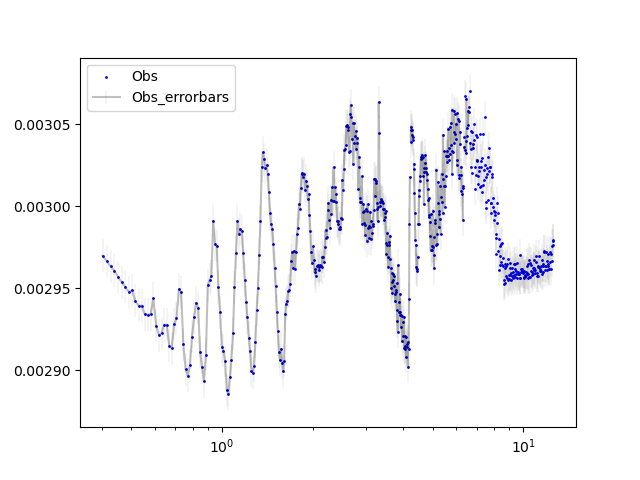

In [6]:
#Load the observed spectrum and bin it to the model resolution
obs = ObservedSpectrum('/workspaces/ML_workspace/Taurex/K2-18b_assignment3_taskA_spectrum.dat')
#Make a logarithmic grid or a linear in the wavelength
wngrid = np.sort(10000/np.linspace(0.3,13,1000))
bn = SimpleBinner(wngrid=wngrid)

bin_obs= bn.bindown(obs.wavenumberGrid, obs.spectrum)
errorbars = bn.bindown(obs.wavenumberGrid, obs.errorBar)


plt.figure()
plt.xscale('log')
plt.scatter(1e4/wngrid, bin_obs[1], label='Obs', c='b', s=1)
plt.errorbar(1e4/wngrid, bin_obs[1], yerr=errorbars[1], label='Obs_errorbars', c='k', markersize=2, alpha=0.25, elinewidth=0.25)
plt.legend()
plt.show()

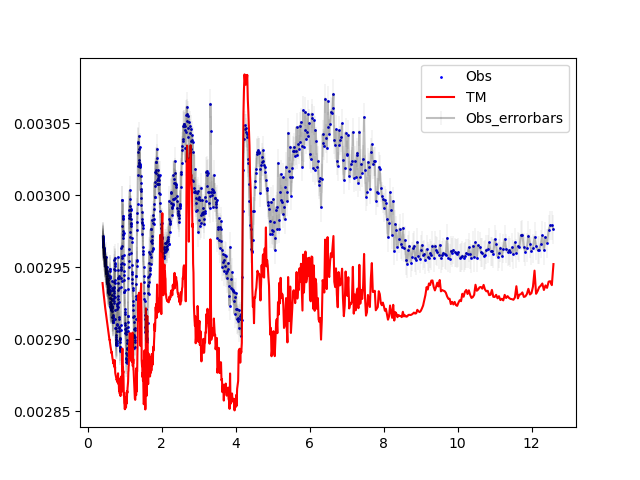

In [7]:
#Binning the native model spectrum to the observed spectrum's wavelength grid
obin = obs.create_binner()
plt.figure()
plt.scatter(obs.wavelengthGrid, obs.spectrum, label='Obs', c='b', s=1)
plt.errorbar(obs.wavelengthGrid,obs.spectrum,obs.errorBar,label='Obs_errorbars',c='k',markersize=2,alpha=0.25,elinewidth=0.25)
plt.plot(obs.wavelengthGrid,obin.bin_model(tm.model(obs.wavenumberGrid))[1],label='TM', c='r')
plt.legend()
plt.show()

In [8]:
#Setting up the nestle optimizer for the retrieval
opt = NestleOptimizer(num_live_points=50)

#Setting up the model and observed spectrum for the optimizer
opt.set_model(tm)
opt.set_observed(obs)

#Set up which parameters to fit and their boundaries
opt.enable_fit('planet_radius')
opt.enable_fit('T')
opt.enable_fit('H2O')
opt.enable_fit('CH4')
opt.enable_fit('CO2')
opt.enable_fit('CO')
opt.set_boundary('T',[200,400])
opt.set_boundary('planet_radius',[0.1,0.3])
opt.set_boundary('H2O',[1e-8,1e-2])
opt.set_boundary('CH4',[1e-8,1e-2])
opt.set_boundary('CO2',[1e-8,1e-2])
opt.set_boundary('CO',[1e-8,1e-2])

In [10]:
#Fit the model to the observed spectrum (quello che devi runnare Nicholas)
fit_output = opt.fit()
taurex.log.disableLogging()

it=  1415 logz=10550.0543163987niter: 1416
ncall: 3729
nsamples: 1466
logz: 10550.279 +/-  0.704
h: 24.800


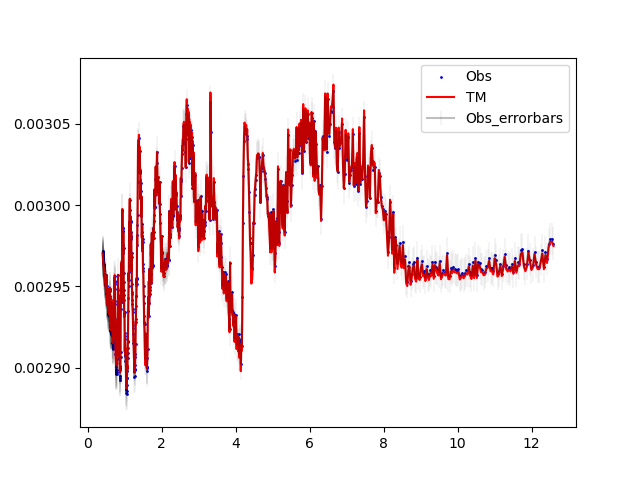

Results saved to /workspaces/ML_workspace/Taurex/assignment3_taskC.txt


In [ ]:
# Define output filename
output_file = '/workspaces/ML_workspace/Taurex/assignment3_taskC.txt'

# Open file to write results
with open(output_file, 'w') as f:
    # Save Input (Fixed) Parameters
    f.write("================ INPUT / FIXED PARAMETERS ================\n")
    f.write(f"Planet Mass:     {tm.planet.mass}\n")
    f.write(f"Star Temperature:{tm.star.temperature}\n")
    f.write(f"Star Radius:     {tm.star.radius}\n")
    f.write(f"Min Pressure:    {tm.pressure.profile[-1]}\n")
    f.write(f"Max Pressure:    {tm.pressure.profile[0]}\n")
    f.write(f"Num Layers:      {tm.nLayers}\n")
    f.write("\n")

    # Save Retrieved Parameters with Error Bars
    f.write("================ RETRIEVED PARAMETERS ================\n")
    f.write(f"{'Parameter':<20} {'Median':<15} {'+1sigma':<15} {'-1sigma':<15} {'Best-Fit (Map)':<15}\n")
    f.write("-" * 85 + "\n")

    # Iterate through the solution
    for sol_idx, map, median, extra in opt.get_solution():
        
        # Update model with best fit parameters for the plot later
        opt.update_model(map)

        samples = opt.get_samples(sol_idx)
        param_names = opt.fit_names

        for i, name in enumerate(param_names):
            s = samples[:, i]
            
            # Calculate 16th, 50th (Median), and 84th percentiles
            q16, q50, q84 = np.percentile(s, [16, 50, 84])
            
            sigma_plus = q84 - q50
            sigma_minus = q50 - q16
            best_fit_val = median[i]

            # Write formatted line to file
            f.write(f"{name:<20} {q50:<15.5e} {sigma_plus:<15.5e} {sigma_minus:<15.5e} {best_fit_val:<15.5e}\n")

        # # Save Statistics (Evidence)
        # f.write("\n================ STATISTICS ================\n")
        # logz = fit_output.get('logz', 10550.279)
        # logzerr = fit_output.get('logzerr', 0.704)
        # f.write(f"Log Evidence (ln Z): {logz:.5f} +/- {logzerr:.5f}\n")
        
        # Plotting
        png_plot = plt.figure()
        plt.scatter(obs.wavelengthGrid, obs.spectrum, label='Obs', c='b', s=1)
        plt.errorbar(obs.wavelengthGrid, obs.spectrum, obs.errorBar, label='Obs_errorbars', c='k', markersize=2, alpha=0.25, elinewidth=0.25)
        plt.plot(obs.wavelengthGrid, obin.bin_model(tm.model(obs.wavenumberGrid))[1], label='TM', c='r')
        plt.legend()
        plt.show()

# Saving the plot of the fitted transmission spectrum
png_plot.savefig('/workspaces/ML_workspace/Taurex/assignment3_taskC.png')
print(f"Results saved to {output_file}")

In [ ]:
# #Plot the fitted spectrum against the observed one
# for solution,optimized_map,optimized_value,values in opt.get_solution():
#     opt.update_model(optimized_map)
#     png_plot = plt.figure()
#     plt.scatter(obs.wavelengthGrid, obs.spectrum, label='Obs', c='b', s=1)
#     plt.errorbar(obs.wavelengthGrid,obs.spectrum,obs.errorBar,label='Obs_errorbars',c='k',markersize=2,alpha=0.25,elinewidth=0.25)
#     plt.plot(obs.wavelengthGrid,obin.bin_model(tm.model(obs.wavenumberGrid))[1],label='TM', c='r')
#     plt.legend()
#     plt.show()
# #Saving the plot of the fitted transmission spectrum
# png_plot.savefig('/workspaces/ML_workspace/Taurex/assignment3_taskC.png')